# Time Series Features

Visualizations can give us intuition on our data. It is also a great tool for communicating insights from our data.

However, numbers are the language of operating a business. This is why we look into what is known as "features" of time series; which may be grouped into:

- **Statistics**: mean, median, minimum, maximum, ..etc.
- **ACF features**: features dervied from auto-correlation.
- **STL features**: features derived from  from the STL method ($y_t = T_t + S_t + R_t$)

Fortunately, we have the package [Nixtla/tsfeatures](https://github.com/Nixtla/tsfeatures) which is a Python implementation of the R package `tsfeatures`; to calculate `+40` time series features with one line of code.

In [17]:
import tsfeatures

## Use Case: Tourism Dataset

In this notebook, we will do **Exploratory Data Analysis (EDA)** on the **Australia Tourism Dataset**. The first is to understand the data from its source: https://tsibble.tidyverts.org/reference/tourism.html

> A dataset containing the quarterly overnight trips from 1998 Q1 to 2016 Q4 across Australia.
>
> ## Format
> 
> A tsibble with 23,408 rows and 5 variables:
> 
> - **Quarter**: Year quarter (index)
>     
> - **Region**: The tourism regions are formed through the aggregation of Statistical Local Areas (SLAs) which are defined by the various State and Territory tourism authorities according to their research and marketing needs
>     
> - **State**: States and territories of Australia
>     
> - **Purpose**: Stopover purpose of visit:
>     
>     - "Holiday"
>         
>     - "Visiting friends and relatives"
>         
>     - "Business"
>         
>     - "Other reason"
>         
> - **Trips**: Overnight trips in thousands

## Loading Data and Preprocessing

In [18]:
from pathlib import Path
import sys

# Make local imports work for this notebook
LESSON_DIR = Path().resolve()
COURSE_DIR = LESSON_DIR.parent
if str(COURSE_DIR) not in sys.path:
    sys.path.insert(0, str(COURSE_DIR))

In [19]:
from utils import load_tourism

tourism = load_tourism()
tourism

Trips
Region          State           Purpose  Quarter            
Adelaide        South Australia Business 1998Q1   135.077690
                                         1998Q2   109.987316
                                         1998Q3   166.034687
                                         1998Q4   127.160464
                                         1999Q1   137.448533
...                                                      ...
Yorke Peninsula South Australia Visiting 2016Q4    33.672151
                                         2017Q1    46.223014
                                         2017Q2    50.582837
                                         2017Q3    27.766728
                                         2017Q4    46.281578

[24320 rows x 1 columns]

### Data Format Conversion

To process our dataset through the `tsfeatures` library, we need to have our data in a **panel format**, i.e.:

In [20]:
import pandas as pd

panel_df = pd.DataFrame({
    'unique_id': ['Product_A', 'Product_A', 'Product_B', 'Product_B'],
    'ds': pd.to_datetime(['2026-07-01', '2026-07-02', '2026-07-01', '2026-07-02']),
    'y': [150, 165, 89, 95]
})

panel_df

,unique_id,ds,y
0,Product_A,2026-07-01,150
1,Product_A,2026-07-02,165
2,Product_B,2026-07-01,89
3,Product_B,2026-07-02,95


Notice how the same `unique_id` repeats for different time points (`ds`).

Hence,

- we'll flatten that multi-index structure
- and string together the `unique_id` from the other columns

In [21]:
# Flatten the multi-index structure
tourism_flat = tourism.reset_index()

# Convert the "Quarter" column from a string to a timestamp
tourism_flat["Quarter"] = tourism_flat["Quarter"].dt.to_timestamp()

# String together the "unique_id" from the other columns
tourism_flat["unique_id"] = tourism_flat.apply(lambda row: f"{row['Region']}_{row['State']}_{row['Purpose']}", axis=1)

tourism_flat

,Region,State,Purpose,Quarter,Trips,unique_id
0,Adelaide,South Australia,Business,1998-01-01,135.077690,Adelaide_South Australia_Business
1,Adelaide,South Australia,Business,1998-04-01,109.987316,Adelaide_South Australia_Business
2,Adelaide,South Australia,Business,1998-07-01,166.034687,Adelaide_South Australia_Business
3,Adelaide,South Australia,Business,1998-10-01,127.160464,Adelaide_South Australia_Business
4,Adelaide,South Australia,Business,1999-01-01,137.448533,Adelaide_South Australia_Business
...,...,...,...,...,...,...
24315,Yorke Peninsula,South Australia,Visiting,2016-10-01,33.672151,Yorke Peninsula_South Australia_Visiting
24316,Yorke Peninsula,South Australia,Visiting,2017-01-01,46.223014,Yorke Peninsula_South Australia_Visiting
24317,Yorke Peninsula,South Australia,Visiting,2017-04-01,50.582837,Yorke Peninsula_South Australia_Visiting
24318,Yorke Peninsula,South Australia,Visiting,2017-07-01,27.766728,Yorke Peninsula_South Australia_Visiting


This snippet might look out of place, but trust me we will need it later to make the analysis easier. We want to keep the relationship between the original multi-indexed dataframe and the flattened one; since the former is easier to query by column, but the latter is what `tsfeatures` accept.

In [22]:
# one metadata row per series (reused when joining features)
series_keys = (
    tourism_flat
    .groupby("unique_id", as_index=False)
    .first()[["unique_id", "Region", "State", "Purpose"]]
)
series_keys

,unique_id,Region,State,Purpose
0,Adelaide Hills_South Australia_Business,Adelaide Hills,South Australia,Business
1,Adelaide Hills_South Australia_Holiday,Adelaide Hills,South Australia,Holiday
2,Adelaide Hills_South Australia_Other,Adelaide Hills,South Australia,Other
3,Adelaide Hills_South Australia_Visiting,Adelaide Hills,South Australia,Visiting
4,Adelaide_South Australia_Business,Adelaide,South Australia,Business
...,...,...,...,...
299,Wimmera_Victoria_Visiting,Wimmera,Victoria,Visiting
300,Yorke Peninsula_South Australia_Business,Yorke Peninsula,South Australia,Business
301,Yorke Peninsula_South Australia_Holiday,Yorke Peninsula,South Australia,Holiday
302,Yorke Peninsula_South Australia_Other,Yorke Peninsula,South Australia,Other


Note the above dataframe is not the data; it is just a mapping of the unique id to it's original three sub components.

We continue our way to conversion by dropping and renaming.

Rename the two columns:

- The time columns `Quarter` to `ds`
- The value column `Trips` to `y`

In [25]:
tourism_panel = (
    tourism_flat
    .drop(columns=["Region", "State", "Purpose"])
    .rename(
        columns={
            "Quarter": "ds",
            "Trips": "y"
        }
    )
)[["unique_id", "ds", "y"]]
tourism_panel

,unique_id,ds,y
0,Adelaide_South Australia_Business,1998-01-01,135.077690
1,Adelaide_South Australia_Business,1998-04-01,109.987316
2,Adelaide_South Australia_Business,1998-07-01,166.034687
3,Adelaide_South Australia_Business,1998-10-01,127.160464
4,Adelaide_South Australia_Business,1999-01-01,137.448533
...,...,...,...
24315,Yorke Peninsula_South Australia_Visiting,2016-10-01,33.672151
24316,Yorke Peninsula_South Australia_Visiting,2017-01-01,46.223014
24317,Yorke Peninsula_South Australia_Visiting,2017-04-01,50.582837
24318,Yorke Peninsula_South Australia_Visiting,2017-07-01,27.766728


Now the data is ready to be processed by `tsfeatures`

## Feature Extraction

The [R package's tsfeatures docs](https://pkg.robjhyndman.com/tsfeatures/reference/index.html) includes description of each of the extracted features. 

We will focus our attention on three groups:

In [26]:
from tsfeatures import (
    statistics,   # mean, median, quantiles, …
    acf_features, # auto-correlation features
    stl_features, # Trend-cycle, seasonality, and remainder components
)

# Statistics Features

Instead of talking, let's look at the function signature specifically, look at the `Returns` section below:

In [27]:
help(statistics)

Help on function statistics in module tsfeatures.tsfeatures:

statistics(x: <built-in function array>, freq: int = 1) -> Dict[str, float]
    Computes basic statistics of x.

    Parameters
    ----------
    x: numpy array
        The time series.
    freq: int
        Frequency of the time series

    Returns
    -------
    dict
        'total_sum': Total sum of the series.
        'mean': Mean value.
        'variance': variance of the time series.
        'median': Median value.
        'p2point5': 2.5 Percentile.
        'p5': 5 percentile.
        'p25': 25 percentile.
        'p75': 75 percentile.
        'p95': 95 percentile.
        'p97point5': 97.5 percentile.
        'max': Max value.
        'min': Min value.



- Let's run the feature extraction function, specifying the subset to be `statistics` only.
- The `freq` is set to `4` **because we know our readings are Quarterly**; this adjusts the computations to be suitable for time series.

In [28]:
stats_features = tsfeatures.tsfeatures(
    tourism_panel,
    freq=4,                 # quarterly seasonality  (four periods per year);
    features=[statistics],  # only those: mean, median, quantiles, …
    scale=False,            # keep original units (thousands of trips)
)

Now we can sort by the `mean` feature in ascending order, and display the results to see both the top and bottom rows:

In [29]:
means = stats_features.sort_values("mean", ascending=False)
means

,unique_id,total_sum,mean,variance,median,p2point5,p5,p25,p75,p95,p97point5,max,min
271,Sydney_New South Wales_Visiting,59781.597453,747.269968,8035.412407,756.873222,563.971524,589.067602,684.630437,813.584920,881.166737,916.297417,920.775880,516.805798
203,Melbourne_Victoria_Visiting,49511.803282,618.897541,8766.156135,616.704310,471.943686,482.080467,552.509842,669.709571,791.872114,807.269007,985.278401,446.083344
268,Sydney_New South Wales_Business,48163.510696,602.043884,13634.317042,601.364582,401.550094,439.098244,516.538265,659.120613,796.390781,884.191221,948.129364,355.022697
217,North Coast NSW_New South Wales_Holiday,47031.730539,587.896632,13694.301356,569.756142,403.830258,418.762170,504.532949,665.759088,788.800718,814.850302,905.845001,398.308092
269,Sydney_New South Wales_Holiday,44026.149221,550.326865,6540.847198,535.645748,428.368340,443.294202,492.548486,599.944949,667.567436,706.607689,828.317118,409.743041
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Clare Valley_South Australia_Other,71.819923,0.897749,2.356195,0.000000,0.000000,0.000000,0.000000,1.168873,4.472032,5.656021,6.822484,0.000000
34,Barkly_Northern Territory_Other,50.590849,0.632386,1.880179,0.000000,0.000000,0.000000,0.000000,0.653533,2.812414,4.664415,7.345308,0.000000
294,Wilderness West_Tasmania_Other,38.261471,0.478268,1.816730,0.000000,0.000000,0.000000,0.000000,0.309625,1.978035,3.203090,10.278224,0.000000
182,MacDonnell_Northern Territory_Other,35.920346,0.449004,1.008100,0.000000,0.000000,0.000000,0.000000,0.067422,2.789633,3.259962,4.535812,0.000000


### Interpreting the Statistics

- This table shows how busy each place is, from the quietest to the busiest.
- Remember that all the numbers are in **thousands of trips** per quarter (every 3 months).

#### A. Most Visited Destinations

At the top, **`mean = 747.27`** for **Sydney (Visiting)** means about **747,000 trips every quarter**! Sydney is way busier than any other destination.

#### B. Most Quiet Destinations

When you see **`mean = 0.34`** for **Kangaroo Island (Other)**, that translates to about **340 people visited per quarter** (since 0.34 $\times$ 1,000 = 340).

This mean is the lowest in our results; indicating that: "visits to Kangaroo Island with the purpose of (Other) is the least". In other words, barely anyone went there most of the time, and only occasionally did it get busy.

Similarly, **`mean = 0.45`** for **MacDonnell (Other)** means about **450 people per quarter**—still very quiet.

Let's read the other statistics for **Kangaroo Island (Other)**:

- **`total_sum = 27.23`** → About **27,230 people visited in total**, over all the quarters counted.

- **`median = 0`, `p25 = 0`, `p75 = 0`** → Most quarters had **zero** visitors! It was empty almost all the time.

- **`max = 3.97`** → The busiest quarter had about **3,970 trips**. That’s the best it ever got.

- **`variance = 0.717`** → The numbers don’t change a lot, except for a few big jumps.


### Zooming in on a specific city: Adelaide

The above analysis started from the statistics, but now, we flip our perspective to look instead at the entities themselves.

We are interested in **Adelaide** since it is a _Captial City_.

Let's analyze its five-number summary. That is: `min`, `p25`, `median`, `p75`, `max`. These numbers split the observations into four equal-sized groups, so they describe the *shape* of a series, not just its level.

In [30]:
# Five-number summary columns 
quantile_cols = ["min", "p25", "median", "p75", "max"]

# Join human-readable labels, to be able to filter and sort more conveniently
# as we always do in pandas (this is not a tsfeatures-specific operation)
adelaide_stats = stats_features.merge(series_keys, on="unique_id")
adelaide_stats = adelaide_stats.loc[adelaide_stats["Region"] == "Adelaide"]
adelaide_stats = adelaide_stats.sort_values("Purpose")

# Display only the columns we are interested in
adelaide_stats[["Region", "State", "Purpose"] + quantile_cols]

,Region,State,Purpose,min,p25,median,p75,max
4,Adelaide,South Australia,Business,68.725393,133.893462,152.576618,176.935536,242.494368
5,Adelaide,South Australia,Holiday,108.033040,134.626822,153.945007,172.256676,223.557406
6,Adelaide,South Australia,Other,25.901846,43.865901,53.809463,62.523135,107.494657
7,Adelaide,South Australia,Visiting,136.611154,178.915998,205.581736,229.299111,269.535618


#### Observations

For Adelaide "Business" trips: the **median** (the middle value) number of trips per quarter is about 153,000. The **interquartile range** (from the 25th percentile, p25, to the 75th percentile, p75) is between 134,000 and 177,000 trips, indicating relatively low variability and a stable distribution. Even the **minimum** number of trips in a quarter is 69,000. In comparison, the **maximum** for Kangaroo Island is only about 4,000 trips in its busiest quarter.

For Adelaide "Other" trips: the **median** is smaller at about 54,000 trips per quarter, with the **minimum** still as high as 26,000—significantly above typical values for Kangaroo Island.

Just by examining the summary statistics—median, minimum, maximum, and interquartile range—you can see that Adelaide consistently has high activity, while Kangaroo Island generally has very low visitor numbers, punctuated by occasional spikes. The difference is clear even before looking at a time series plot.

### Visualizing the Visit Counts

The same statistics computed above, can be visualized; as the distribution of visit counts for each `Region` and `Purpose`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

The Capital City Adelaide:

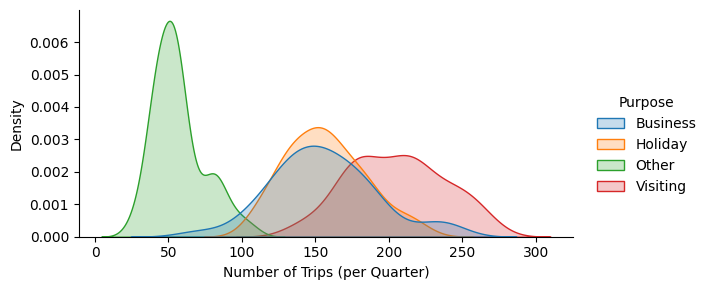

In [45]:
# Select the Adelaide data
adelaide_trips = tourism_flat[tourism_flat["Region"] == "Adelaide"]

# Use displot to create a faceted histogram by Purpose
fg = sns.displot(
    data=adelaide_trips,
    kind='kde',
    fill=True,
    x="Trips",
    hue="Purpose",
    height=3,
    aspect=6/3,  # aspect = width / height
)
fg.set_titles("Distribution of Adelaide Trips by Purpose")
fg.set_xlabels("Number of Trips (per Quarter)");

Let's compare it to Kangaroo Island:

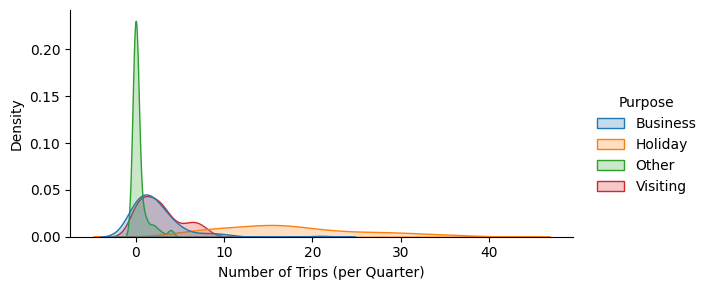

In [44]:
kangaroo_trips = tourism_flat[tourism_flat["Region"] == "Kangaroo Island"]

# Use displot to create a faceted histogram by Purpose
fg = sns.displot(
    data=kangaroo_trips,
    kind='kde',
    fill=True,
    x="Trips",
    hue="Purpose",
    height=3,
    aspect=6/3,  # aspect = width / height
)
fg.set_titles("Distribution of Adelaide Trips by Purpose")
fg.set_xlabels("Number of Trips (per Quarter)");

Notice first that the x-axis scales are different:

- The total number of trips in Adelaide is much higher compared to Kangaroo Island, as shown by the different ranges on the x-axes.

- **Adelide** is very busy with most trips being for **Visiting**. Whereas the **Kangaroo Island** rarely exceeded `40` per quarter trips, throughout the years, and those that do, are for **Holiday**.

- In Adelaide, the distribution for the "Visiting" purpose is clearly dominant, while business and holiday trip purposes are also higher, **reflecting its status as a busy capital city**.

- For Kangaroo Island, the vast majority of trips are for holidays. Business or visiting trips are minimal. The overall number of trips remains well below that of Adelaide, showing that Kangaroo Island is a much less frequented destination and is **primarily a tourism spot**.

This contrast illustrates the difference between a major urban center with varied travel purposes and a remote island destination catering mainly to holidaymakers. 

---